# Sign Language Pattern Association

This notebook demonstrates pattern association between hand-pattern images and command symbols using mockup dataset information.

## Objective
- Load the 10 mockup screenshot images.
- Associate each hand pattern with its command symbol.
- Predict the command for a new input pattern.
- Detect an incorrect association.
- Visualize the learned associations.


In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt


## 1. Define the training associations

The 10 mockup images are assigned to the five hand patterns and their command symbols.

In [2]:
patterns = [
    ("OPEN_HAND", "HELLO"),
    ("FIST", "STOP"),
    ("THUMBS_UP", "YES"),
    ("THUMBS_DOWN", "NO"),
    ("PEACE_SIGN", "PEACE"),
    ("OPEN_HAND", "HELLO"),
    ("FIST", "STOP"),
    ("THUMBS_UP", "YES"),
    ("THUMBS_DOWN", "NO"),
    ("PEACE_SIGN", "PEACE")
]


## 2. Find the screenshot images

The filenames do not need to be renamed. The six-digit time at the end of each screenshot filename is used to put the images in the correct order.

In [4]:
image_folder = "../dataset/images"

image_files = []

for extension in ["*.png", "*.jpg", "*.jpeg"]:
    image_files.extend(glob.glob(os.path.join(image_folder, extension)))

def get_time(filename):
    match = re.search(r'(\d{6})\.(png|jpg|jpeg)$', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    return 0

image_files.sort(key=get_time)

print("Number of images found:", len(image_files))

if len(image_files) != 10:
    print("ERROR: Exactly 10 images are required in dataset/images/")
else:
    print("All 10 images found successfully.")


Number of images found: 10
All 10 images found successfully.


In [5]:
for i, image in enumerate(image_files, start=1):
    print(f"{i}. {os.path.basename(image)}")


1. Screenshot 2026-09-04 175526.png
2. Screenshot 2026-09-04 175549.png
3. Screenshot 2026-09-04 175559.png
4. Screenshot 2026-09-04 175610.png
5. Screenshot 2026-09-04 175619.png
6. Screenshot 2026-09-04 175640.png
7. Screenshot 2026-09-04 175646.png
8. Screenshot 2026-09-04 175658.png
9. Screenshot 2026-09-04 175704.png
10. Screenshot 2026-09-04 175714.png


## 3. Create the mock training dataset

In [6]:
data = []

for i in range(10):
    data.append({
        "Pattern_ID": i + 1,
        "Image": os.path.basename(image_files[i]),
        "Hand_Pattern": patterns[i][0],
        "Command_Symbol": patterns[i][1]
    })

df = pd.DataFrame(data)

df


,Pattern_ID,Image,Hand_Pattern,Command_Symbol
0,1,Screenshot 2026-09-04 175526.png,OPEN_HAND,HELLO
1,2,Screenshot 2026-09-04 175549.png,FIST,STOP
2,3,Screenshot 2026-09-04 175559.png,THUMBS_UP,YES
3,4,Screenshot 2026-09-04 175610.png,THUMBS_DOWN,NO
4,5,Screenshot 2026-09-04 175619.png,PEACE_SIGN,PEACE
5,6,Screenshot 2026-09-04 175640.png,OPEN_HAND,HELLO
6,7,Screenshot 2026-09-04 175646.png,FIST,STOP
7,8,Screenshot 2026-09-04 175658.png,THUMBS_UP,YES
8,9,Screenshot 2026-09-04 175704.png,THUMBS_DOWN,NO
9,10,Screenshot 2026-09-04 175714.png,PEACE_SIGN,PEACE


## 4. Display the hand-pattern images with their associations

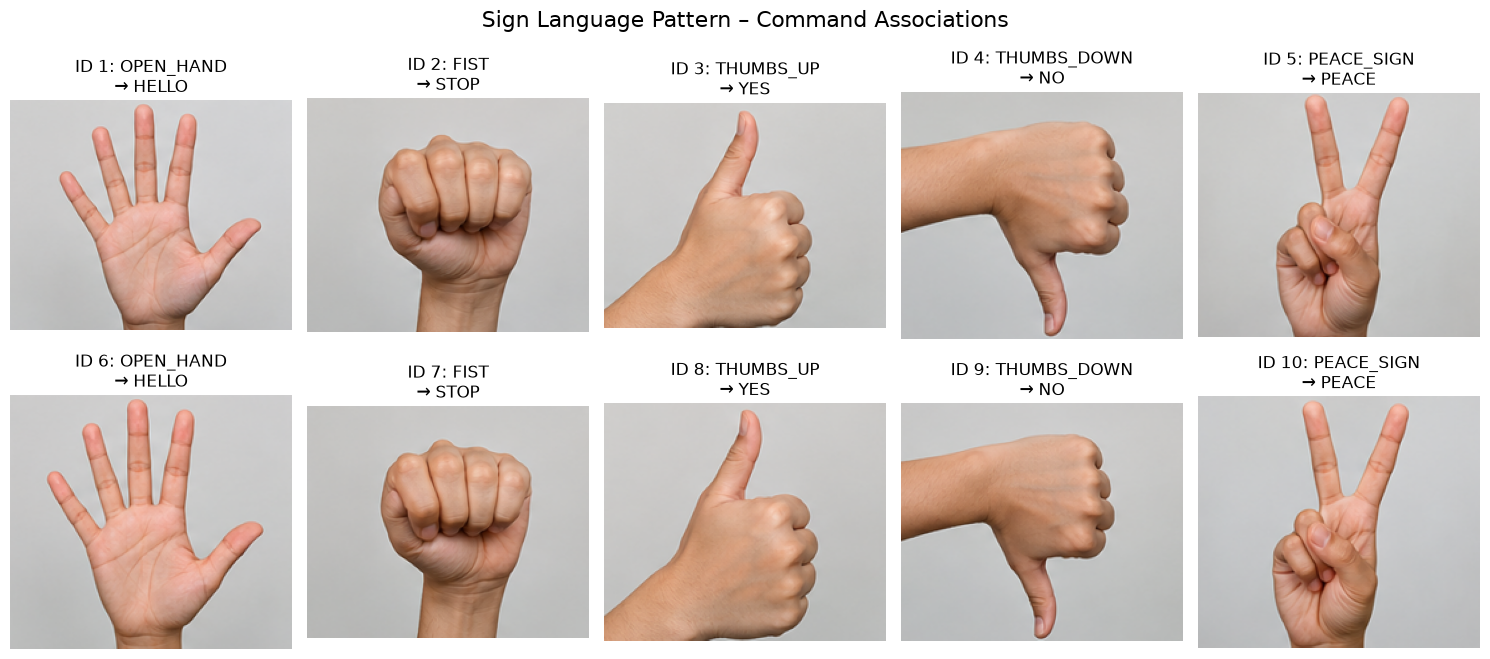

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, ax in enumerate(axes.flat):
    image = plt.imread(image_files[i])
    ax.imshow(image)
    ax.set_title(
        f"ID {i+1}: {patterns[i][0]}\n→ {patterns[i][1]}"
    )
    ax.axis("off")

plt.suptitle("Sign Language Pattern – Command Associations", fontsize=16)
plt.tight_layout()
plt.show()


## 5. Learn the pattern associations

The system creates a simple association dictionary where each hand pattern is connected to its command symbol.

In [8]:
association = {}

for _, row in df.iterrows():
    association[row["Hand_Pattern"]] = row["Command_Symbol"]

print("Learned Associations")
print("--------------------")

for pattern, command in association.items():
    print(f"{pattern} -> {command}")


Learned Associations
--------------------
OPEN_HAND -> HELLO
FIST -> STOP
THUMBS_UP -> YES
THUMBS_DOWN -> NO
PEACE_SIGN -> PEACE


## 6. Test a new input pattern

In [9]:
new_input = "OPEN_HAND"
predicted_command = association.get(new_input)

print("New Input:", new_input)
print("Predicted Command:", predicted_command)


New Input: OPEN_HAND
Predicted Command: HELLO


## 7. Check the expected mapping

In [10]:
expected_command = "HELLO"

print("Expected Command:", expected_command)

if predicted_command == expected_command:
    print("Association Status: CORRECT")
else:
    print("Association Status: INCORRECT")


Expected Command: HELLO
Association Status: CORRECT


## 8. Detect an incorrect association

Here, OPEN_HAND is deliberately paired with STOP. The learned association says OPEN_HAND should map to HELLO, so the system detects the mismatch.

In [11]:
wrong_command = "STOP"

print("Input Pattern:", new_input)
print("Given Command:", wrong_command)

if association.get(new_input) != wrong_command:
    print("Result: INCORRECT ASSOCIATION DETECTED")
else:
    print("Result: Association is correct")


Input Pattern: OPEN_HAND
Given Command: STOP
Result: INCORRECT ASSOCIATION DETECTED


## 9. Analyze the number of patterns


In [12]:
pattern_counts = df["Hand_Pattern"].value_counts()

print("Pattern Counts")
print("--------------")
print(pattern_counts)


Pattern Counts
--------------
Hand_Pattern
OPEN_HAND      2
FIST           2
THUMBS_UP      2
THUMBS_DOWN    2
PEACE_SIGN     2
Name: count, dtype: int64


## 10. Visualize the associations

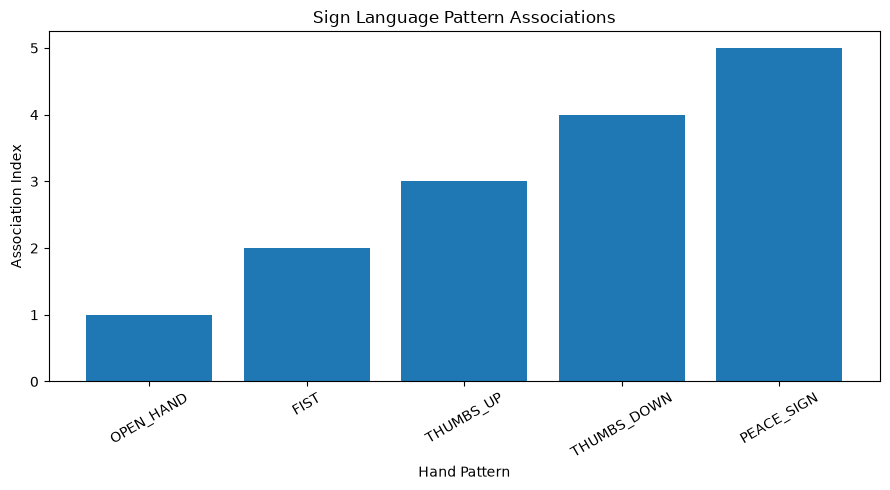

In [ ]:
output_folder = "../results"
os.makedirs(output_folder, exist_ok=True)

plt.figure(figsize=(9, 5))
plt.bar(
    list(association.keys()),
    range(1, len(association) + 1)
)
plt.title("Sign Language Pattern Associations")
plt.xlabel("Hand Pattern")
plt.ylabel("Association Index")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(os.path.join(output_folder, "pattern_analysis.png"))
plt.show()


## 11. Final Result


In [14]:
print("==============================================")
print("                 FINAL RESULT")
print("==============================================")
print("Input Pattern :", new_input)
print("Command       :", predicted_command)
print("Status        : Association Successfully Identified")
print("\nProgram completed successfully!")


                 FINAL RESULT
Input Pattern : OPEN_HAND
Command       : HELLO
Status        : Association Successfully Identified

Program completed successfully!
